<a href="https://colab.research.google.com/github/Annaa74/Google-colab-models/blob/main/linearRegressionFromScratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install scikit-learn

In [ ]:
import pandas as pd

In [ ]:
from sklearn.datasets import fetch_california_housing

In [ ]:
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
df = fetch_california_housing()

In [ ]:
df

In [ ]:
dataset = pd.DataFrame(df.data)

In [ ]:
dataset.columns = df.feature_names

In [ ]:
dataset.head()

In [ ]:
## independent features and dependent features

X = dataset
Y = df.target

In [ ]:
Y

In [ ]:
# train test split
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.3, random_state = 42)


In [ ]:
X_train

In [ ]:
## standarddizing the dataset
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()


In [ ]:
scaler.fit_transform(X_train)

In [ ]:
scaler.transform(X_test)

In [ ]:
from sklearn.linear_model import LinearRegression

### cross valiation

from sklearn.model_selection import cross_val_score

In [ ]:
reg = LinearRegression()
reg.fit(X_train,Y_train)

In [ ]:
mse = cross_val_score(reg, X_train, Y_train,scoring  ='neg_mean_squared_error', cv = 5 )

In [ ]:
np.mean(mse)

In [ ]:
reg_predict = reg.predict(X_test)

In [ ]:
reg_predict

In [ ]:
import seaborn as sns

sns.displot(reg_predict - Y_test, kind = 'kde')

In [ ]:
from sklearn.metrics import r2_score
score = r2_score(reg_predict, Y_test)


In [ ]:
score

Linear regression from  scratchy scratch


In [64]:
class LinearRegression:

      def __init__(self, lr= 0.01, n_iters = 1000):
            self.lr = lr
            self.n_iters = n_iters
            self.weights = None
            self.bias = None
      def fit(self,X,y):
          n_samples, n_features = X.shape
          self.weights = np.zeros(n_features)
          self.bias = 0
          for _ in range(self.n_iters):
                y_pred = np.dot(X, self.weights) + self.bias

                dw = (1/n_samples) * np.dot(X.T, (y_pred - y))
                db = (1/n_samples) * np.sum(y_pred - y)

                self.weights = self.weights -self.lr*dw
                self.bias = self.bias - self.lr * db
      def pred(self, X):
          y_pred = np.dot(X,self.weights) +self.bias
          return y_pred


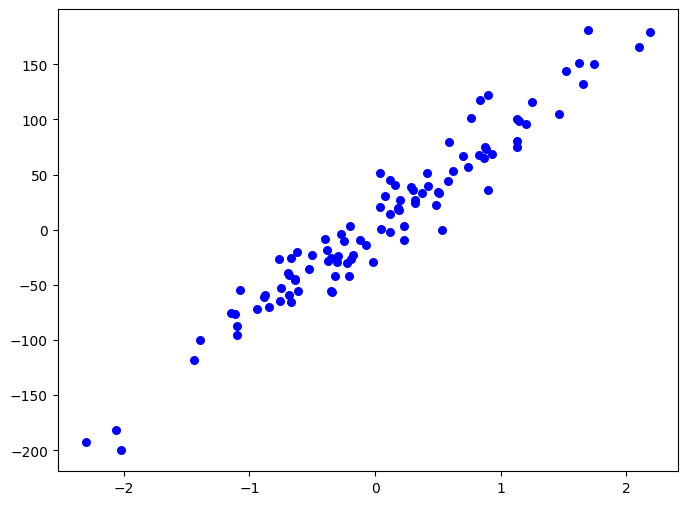

293.8230552855369


In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split


X,y = make_regression(n_samples = 100, n_features = 1 , noise = 20, random_state = 1)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size =0.20, random_state = 42)

fig = plt.figure(figsize = (8,6))
plt.scatter(X[:, 0],y, color = "b", marker = "o", s = 30)
plt.show()

reg = LinearRegression()
reg.fit(X_train,y_train)
pred = reg.pred(X_test)


def mse(y_test, pred):
  return np.mean((y_test - pred)**2)
mse = mse(y_test, pred)

print(mse)




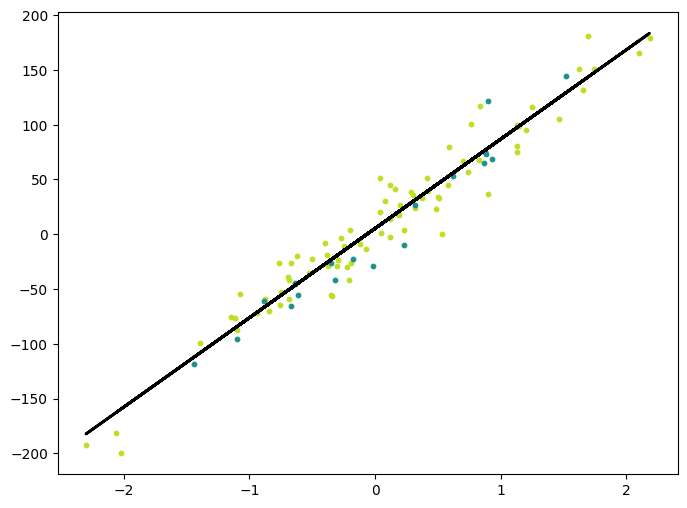

In [66]:
y_pred_line = reg.pred(X)
cmap = plt.get_cmap("viridis")
fig = plt.figure(figsize = (8,6))
m1 = plt.scatter(X_train, y_train, color = cmap(0.9), s = 10)
m2 = plt.scatter(X_test, y_test, color = cmap(0.5), s = 10)
plt.plot(X, y_pred_line, color = "black", linewidth = 2, label = "Prediction")
plt.show()